In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned/customer_clean.csv")

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["TenureScore"] = scaler.fit_transform(
    df[["tenure"]]
)

df["MonthlyScore"] = scaler.fit_transform(
    df[["MonthlyCharges"]]
)

df["TotalScore"] = scaler.fit_transform(
    df[["TotalCharges"]]
)

In [4]:
contract_map = {
    "Month-to-month": 0,
    "One year": 50,
    "Two year": 100
}

df["ContractScore"] = (
    df["Contract"]
    .map(contract_map)
)

In [5]:
df[["Contract","ContractScore"]].head()

,Contract,ContractScore
0,Month-to-month,0
1,One year,50
2,Month-to-month,0
3,One year,50
4,Month-to-month,0


In [6]:
df["CustomerScore"] = (
      0.4 * df["TenureScore"]
    + 0.2 * df["MonthlyScore"]
    + 0.4 * df["TotalScore"]
)

df["CustomerScore"] *= 100

In [7]:
def segment_customer(score):

    if score >= 80:
        return "Champion"

    elif score >= 60:
        return "Loyal"

    elif score >= 40:
        return "Potential Loyalist"

    elif score >= 20:
        return "At Risk"

    else:
        return "Lost"

In [8]:
df["Segment"] = df["CustomerScore"].apply(
    segment_customer
)

In [9]:
df["Segment"].value_counts()

Segment
Lost                  2350
At Risk               1768
Potential Loyalist    1294
Loyal                  992
Champion               639
Name: count, dtype: int64

In [10]:
df["HealthScore"] = (
      0.30 * (df["TenureScore"] * 100)
    + 0.25 * (df["TotalScore"] * 100)
    + 0.15 * (df["MonthlyScore"] * 100)
    + 0.30 * df["ContractScore"]
)

In [11]:
df["HealthScore"].describe()

count    7043.000000
mean       37.349540
std        27.049146
min         0.560480
25%        13.159765
50%        32.147761
75%        58.558709
max        99.964449
Name: HealthScore, dtype: float64

In [12]:
def classify_risk(score):

    if score >= 70:
        return "Low Risk"

    elif score >= 40:
        return "Medium Risk"

    else:
        return "High Risk"

In [13]:
df["RiskLevel"] = (
    df["HealthScore"]
    .apply(classify_risk)
)

In [14]:
df["RiskLevel"].value_counts()

RiskLevel
High Risk      4103
Medium Risk    1883
Low Risk       1057
Name: count, dtype: int64

In [15]:
df.groupby("RiskLevel")[
    ["tenure","MonthlyCharges","TotalCharges"]
].mean().round(2)

,tenure,MonthlyCharges,TotalCharges
RiskLevel,,,
High Risk,14.95,58.81,902.99
Low Risk,66.63,91.77,6114.17
Medium Risk,51.10,62.58,3127.21


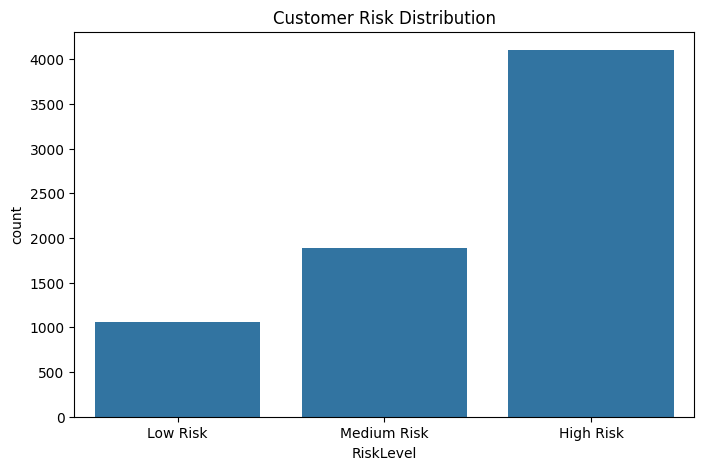

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="RiskLevel",
    data=df,
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title("Customer Risk Distribution")
plt.show()

# Customer Health Score Analysis

A custom Health Score was developed using customer tenure, monthly charges, total charges, and contract commitment.

Customers were classified into three risk categories:

- Low Risk: Strong loyalty and retention indicators.
- Medium Risk: Moderate retention risk requiring monitoring.
- High Risk: Customers most vulnerable to churn.

## Key Findings

- Approximately 58% of customers were classified as High Risk.
- Approximately 27% were classified as Medium Risk.
- Approximately 15% were classified as Low Risk.

The results suggest that a substantial portion of the customer base may require proactive retention strategies.

In [17]:
def recommendation(risk):

    if risk == "High Risk":
        return "Offer retention discount"

    elif risk == "Medium Risk":
        return "Send engagement campaign"

    return "Provide loyalty rewards"

df["Recommendation"] = (
    df["RiskLevel"]
    .apply(recommendation)
)

In [18]:
df[
    [
        "customerID",
        "HealthScore",
        "RiskLevel",
        "Recommendation"
    ]
].head(10)

,customerID,HealthScore,RiskLevel,Recommendation
0,7590-VHVEG,2.233936,High Risk,Offer retention discount
1,5575-GNVDE,40.381887,Medium Risk,Send engagement campaign
2,3668-QPYBK,6.458086,High Risk,Offer retention discount
3,7795-CFOCW,42.638321,Medium Risk,Send engagement campaign
4,9237-HQITU,9.098230,High Risk,Offer retention discount
5,9305-CDSKC,17.844472,High Risk,Offer retention discount
6,1452-KIOVK,25.352822,High Risk,Offer retention discount
7,6713-OKOMC,6.752132,High Risk,Offer retention discount
8,7892-POOKP,33.352914,High Risk,Offer retention discount
9,6388-TABGU,56.530436,Medium Risk,Send engagement campaign


In [19]:
df.to_csv(
    "../data/cleaned/customer_health_dataset.csv",
    index=False
)